# Gradient Descent for Least Squares (Linear Regression with Many Observations)

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on **gradient descent for least
squares** (Week 2 — Gradients and Gradient Descent).

This notebook explains:

- how the power-line **cost** becomes a **surface** over the parameters $(m, b)$ — and how
  descending it solves **linear regression**
- the **advertising** example: predict sales from a TV budget with $y = mx + b$
- the least-squares cost over $n$ observations
  $L(m,b) = \frac{1}{2n}\sum_i (m x_i + b - y_i)^2$
- the gradient of $L$ and the gradient-descent update on $(m, b)$
- a full implementation on the real **TV-marketing** dataset, checked against the exact
  least-squares solution

This notebook follows the repository `GUIDELINES.md` template and continues directly
from *Gradient Descent in Two Variables* and *Optimization Using Gradients — Analytical
Method*.

## 1. The cost as a surface over $(m, b)$

Recall the power-line problem: a line $y = mx + b$ tries to fit some points, and the cost
is the **sum of squared** vertical distances.

> *"This line is parameterized by the slope and the $y$-intercept, $m$ and $b$. Put $m$ and
> $b$ on the two floor axes; at the point $(m, b)$ plot the height of the cost function."*

So every choice of $(m, b)$ is a point on the floor, and the cost is the **height** above
it — a surface.

- A **good** fit (small error) sits **low** in the surface.
- An **awful** fit (large error) sits **high**.

> *"In the plot on the right you use gradient descent to get to the very bottom and
> minimize the cost. As you do that you change $m$ and $b$, and the line on the left
> becomes a better fit. That's how you solve linear regression using gradient descent."*

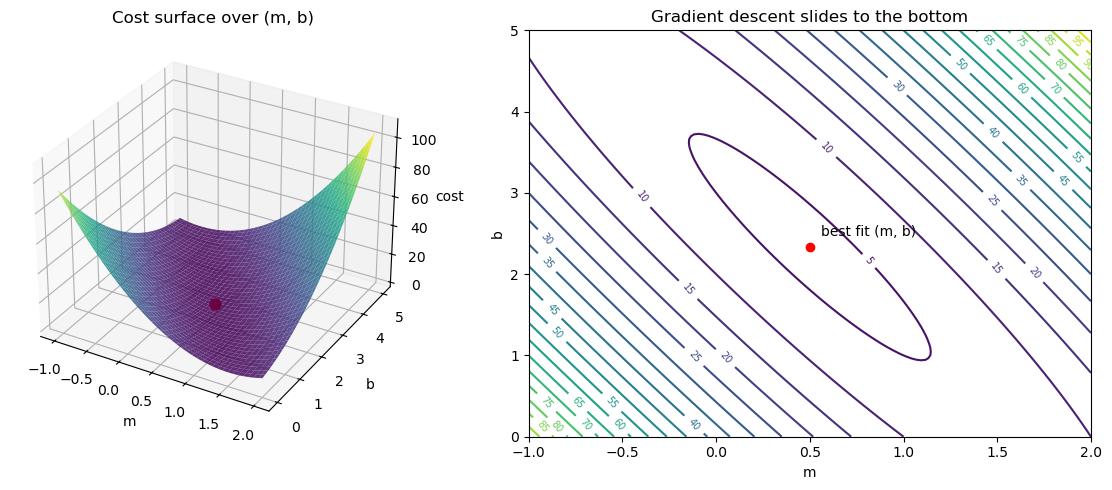

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# the three power-line points from the analytical-method lecture
pts = np.array([(1, 2), (2, 5), (3, 3)], dtype=float)

def cost_mb(m, b):
    return sum((m*px + b - py)**2 for (px, py) in pts)

mm = np.linspace(-1, 2, 120)
bb = np.linspace(0, 5, 120)
MM, BB = np.meshgrid(mm, bb)
ZZ = np.array([[cost_mb(m, b) for m in mm] for b in bb])

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_surface(MM, BB, ZZ, cmap="viridis", alpha=0.85)
ax.scatter([0.5], [7/3], [cost_mb(0.5, 7/3)], color="red", s=60)
ax.set_title("Cost surface over (m, b)")
ax.set_xlabel("m"); ax.set_ylabel("b"); ax.set_zlabel("cost")

ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contour(MM, BB, ZZ, levels=20, cmap="viridis")
ax2.clabel(cs, inline=True, fontsize=7)
ax2.plot(0.5, 7/3, "ro")
ax2.annotate("best fit (m, b)", (0.5, 7/3), textcoords="offset points", xytext=(8, 8))
ax2.set_title("Gradient descent slides to the bottom")
ax2.set_xlabel("m"); ax2.set_ylabel("b")
plt.tight_layout()
plt.show()

## 2. The advertising example

> *"You work in an agency with a TV advertising budget that relates to number of sales...
> The goal is to predict sales in terms of the TV budget. The first tool is linear
> regression: find a line $y = mx + b$."*

We use the real **TV-marketing** dataset: each row is a TV budget $x_i$ and the resulting
sales $y_i$.

      TV  Sales
0  230.1   22.1
1   44.5   10.4
2   17.2    9.3
3  151.5   18.5
4  180.8   12.9

200 observations


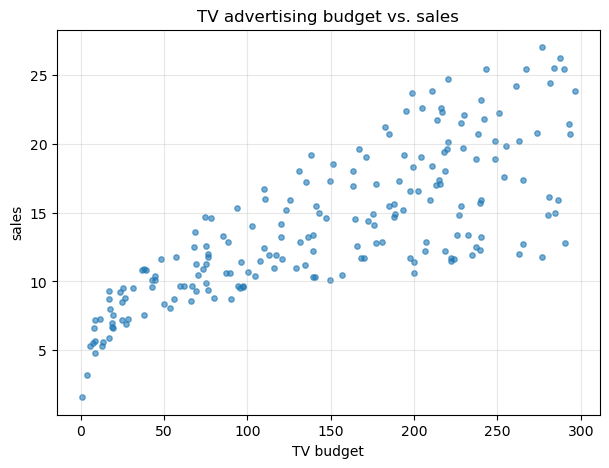

In [2]:
import pandas as pd

df = pd.read_csv("../data/tvmarketing.csv")
print(df.head())
print(f"\n{len(df)} observations")

x_raw = df["TV"].to_numpy()
y_raw = df["Sales"].to_numpy()

plt.figure(figsize=(7, 5))
plt.scatter(x_raw, y_raw, s=15, alpha=0.6)
plt.title("TV advertising budget vs. sales")
plt.xlabel("TV budget"); plt.ylabel("sales")
plt.grid(True, alpha=0.3)
plt.show()

## 3. The least-squares cost over $n$ observations

> *"Look at the first point $(x_1, y_1)$. The point on the line has the form
> $(x_1,\, m x_1 + b)$, so the distance is $m x_1 + b - y_1$; squaring gives the loss at
> that point. Add all the losses and take the average — divide by $n$ — with an extra 2."*

For each observation the squared loss is $(m x_i + b - y_i)^2$. Averaging over all $n$
points (with the customary $\tfrac12$):

$$
L(m, b) = \frac{1}{2n}\sum_{i=1}^{n} \big(m x_i + b - y_i\big)^2 .
$$

> *"The 2 is there because when we take the derivative, the 2 in the exponent cancels with
> it. But it doesn't really matter — multiplying the cost by a constant doesn't move the
> minimum."*

## 4. The gradient and the update rule

Differentiating $L$ with respect to $m$ and $b$ (the $\tfrac12$ cancels the exponent's 2):

$$
\frac{\partial L}{\partial m} = \frac{1}{n}\sum_{i=1}^{n}\big(m x_i + b - y_i\big)\,x_i,
\qquad
\frac{\partial L}{\partial b} = \frac{1}{n}\sum_{i=1}^{n}\big(m x_i + b - y_i\big).
$$

Then gradient descent updates the parameters together:

$$
\begin{bmatrix} m_k \\ b_k \end{bmatrix}
=
\begin{bmatrix} m_{k-1} \\ b_{k-1} \end{bmatrix}
- \alpha
\begin{bmatrix} \partial L/\partial m \\ \partial L/\partial b \end{bmatrix},
$$

repeated many ($N$) times until the fit is good.

### Normalizing the data

The TV budgets ($\sim$0–300) and sales ($\sim$1–27) live on very different scales, which
makes raw gradient descent unstable. We standardize both to mean 0 / standard deviation 1
so a single learning rate works well. (The relationship is still a line; we can convert
back afterwards if needed.)

In [3]:
x = (x_raw - x_raw.mean()) / x_raw.std()
y = (y_raw - y_raw.mean()) / y_raw.std()

def loss(m, b):
    return np.mean((m*x + b - y)**2) / 2

def grad(m, b):
    err = (m*x + b - y)
    dm = np.mean(err * x)
    db = np.mean(err)
    return np.array([dm, db])

## 5. Running gradient descent

In [4]:
def gradient_descent(grad, m0=0.0, b0=0.0, alpha=0.5, n_iter=1000, tol=1e-9):
    p = np.array([m0, b0], dtype=float)
    history = [p.copy()]
    for _ in range(n_iter):
        step = alpha * grad(*p)
        p = p - step
        history.append(p.copy())
        if np.linalg.norm(step) < tol:
            break
    return p, np.array(history)

(m_fit, b_fit), hist = gradient_descent(grad, alpha=0.5, n_iter=1000)
print(f"gradient descent (normalized): m = {m_fit:.5f}, b = {b_fit:.5f}")

# exact least-squares solution on the same normalized data
m_exact, b_exact = np.polyfit(x, y, 1)
print(f"exact least squares (polyfit) : m = {m_exact:.5f}, b = {b_exact:.5f}")
print(f"iterations: {len(hist) - 1}")

gradient descent (normalized): m = 0.78222, b = -0.00000
exact least squares (polyfit) : m = 0.78222, b = -0.00000
iterations: 30


### The fit and the descent

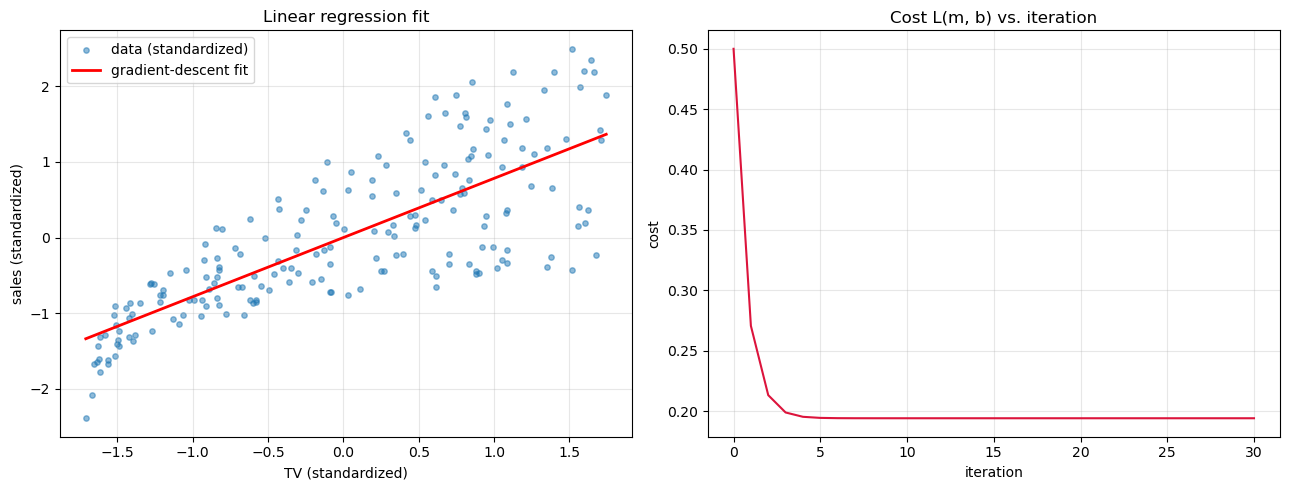

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# fitted line over the (normalized) data
axes[0].scatter(x, y, s=15, alpha=0.5, label="data (standardized)")
xs = np.linspace(x.min(), x.max(), 100)
axes[0].plot(xs, m_fit*xs + b_fit, "r", linewidth=2, label="gradient-descent fit")
axes[0].set_title("Linear regression fit")
axes[0].set_xlabel("TV (standardized)"); axes[0].set_ylabel("sales (standardized)")
axes[0].grid(True, alpha=0.3); axes[0].legend()

# cost vs iteration
costs = [loss(m, b) for (m, b) in hist]
axes[1].plot(costs, color="crimson")
axes[1].set_title("Cost L(m, b) vs. iteration")
axes[1].set_xlabel("iteration"); axes[1].set_ylabel("cost")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### The descent path on the cost surface

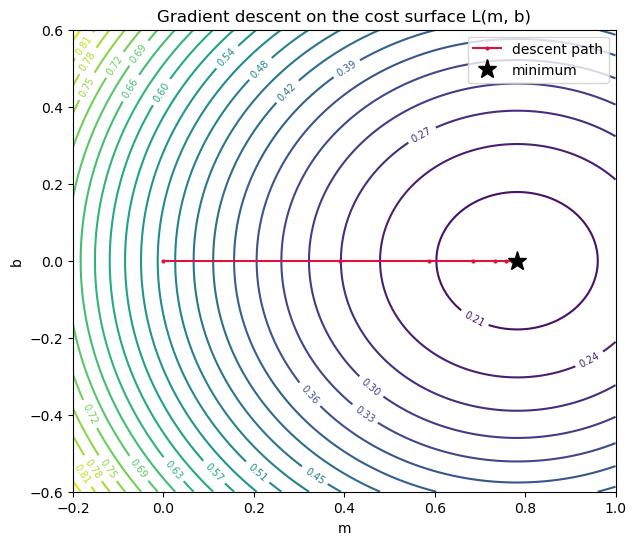

In [6]:
mm = np.linspace(-0.2, 1.0, 120)
bb = np.linspace(-0.6, 0.6, 120)
MM, BB = np.meshgrid(mm, bb)
LL = np.array([[loss(m, b) for m in mm] for b in bb])

plt.figure(figsize=(7, 6))
cs = plt.contour(MM, BB, LL, levels=25, cmap="viridis")
plt.clabel(cs, inline=True, fontsize=7)
plt.plot(hist[:, 0], hist[:, 1], "o-", color="crimson", markersize=2, label="descent path")
plt.plot(m_fit, b_fit, "k*", markersize=14, label="minimum")
plt.title("Gradient descent on the cost surface L(m, b)")
plt.xlabel("m"); plt.ylabel("b")
plt.legend()
plt.show()

## 6. Exercises

### Basic
1. Write the per-observation squared loss for a point $(x_i, y_i)$ and the line $y=mx+b$.
2. Why does multiplying the cost by $\tfrac{1}{2}$ not change the optimal $(m, b)$?

### Intermediate
3. Derive $\partial L/\partial m$ and $\partial L/\partial b$ from
   $L = \frac{1}{2n}\sum (m x_i + b - y_i)^2$.
4. Run gradient descent with a much smaller learning rate (e.g. $\alpha = 0.05$). How many
   more iterations does it need?

### Advanced
5. Confirm the gradient-descent parameters match `np.polyfit` on the standardized data to
   3 decimals.
6. Explain why standardizing the features helps gradient descent converge, in terms of the
   shape of the cost surface.

## 7. Solutions / Checks

In [7]:
# 3. gradient (symbolic sketch) is implemented in grad(); show values at (0,0)
print("3. ∂L/∂m, ∂L/∂b at (0,0) =", np.round(grad(0.0, 0.0), 5),
      "  (matches (1/n)Σ(mx+b-y)x and (1/n)Σ(mx+b-y))")

# 4. smaller learning rate
_, h_slow = gradient_descent(grad, alpha=0.05, n_iter=20000)
print(f"4. α=0.05 took {len(h_slow)-1} iterations (vs {len(hist)-1} at α=0.5)")

# 5. compare to polyfit
print(f"5. GD:      m={m_fit:.3f}, b={b_fit:.3f}")
print(f"   polyfit: m={m_exact:.3f}, b={b_exact:.3f}  -> match:",
      np.allclose([m_fit, b_fit], [m_exact, b_exact], atol=1e-3))

print("6. Standardizing makes the cost surface more bowl-like (circular contours) instead "
      "of a long narrow valley, so a single learning rate descends efficiently.")

3. ∂L/∂m, ∂L/∂b at (0,0) = [-0.78222  0.     ]   (matches (1/n)Σ(mx+b-y)x and (1/n)Σ(mx+b-y))
4. α=0.05 took 342 iterations (vs 30 at α=0.5)
5. GD:      m=0.782, b=-0.000
   polyfit: m=0.782, b=-0.000  -> match: True
6. Standardizing makes the cost surface more bowl-like (circular contours) instead of a long narrow valley, so a single learning rate descends efficiently.


## 8. Conclusion

- Linear regression = finding the $(m, b)$ that **minimize a cost surface**; gradient
  descent slides to its bottom.
- With $n$ observations the least-squares cost is
  $L(m,b) = \frac{1}{2n}\sum_i (m x_i + b - y_i)^2$, and its gradient is the average error
  times the inputs (for $m$) and the average error (for $b$).
- The update $\begin{bmatrix} m_k \\ b_k \end{bmatrix} =
  \begin{bmatrix} m_{k-1} \\ b_{k-1} \end{bmatrix} - \alpha \nabla L$ is iterated until the
  fit is good.
- On the real TV-marketing data, gradient descent recovers the **same** line as exact
  least squares — this is the engine behind training regression models.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/gradient_07.mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 2) lecture on **gradient descent for least squares**. Key spoken points,
lightly cleaned:

> The power-line line $y=mx+b$ is parameterized by $m$ and $b$; put them on the floor axes
> and plot the cost as height — a surface. A good fit sits low, an awful fit sits high.
> Gradient descent slides to the bottom, and as $m, b$ change the line fit improves — that
> solves linear regression. Example: predict sales from a TV advertising budget with
> $y=mx+b$, given many observations $(x_1,y_1),\dots,(x_n,y_n)$. The loss at point $i$ is
> $(m x_i + b - y_i)^2$; average over all points and divide by $n$, with an extra factor 2
> (which cancels the derivative's exponent and doesn't move the minimum). So
> $L(m,b)=\frac{1}{2n}\sum (m x_i + b - y_i)^2$. Start at $(m_0,b_0)$ (a random line) and
> update $(m_k,b_k)=(m_{k-1},b_{k-1}) - \alpha\nabla L$, iterating $N$ times until the fit
> is good — the formal gradient-descent algorithm.